**[Qwen 3](https://qwenlm.github.io/blog/qwen3/)** from **[Alibaba](https://www.reuters.com/world/china/alibaba-launches-open-source-ai-coding-model-touted-its-most-advanced-date-2025-07-23/)** is currently the **best open-source model available**, offering **[state-of-the-art performance](https://lambda.ai/llm-benchmarks-leaderboard)** across a wide range of tasks including **reasoning**, **coding**, **math**, and **multilingual understanding**. Its flagship version, **Qwen3‑235B‑A22B**, ranks at or near the top of key benchmarks like **[MMLU-Pro](https://lambda.ai/llm-benchmarks-leaderboard?)**, **[LiveCodeBench](https://www.datacamp.com/blog/qwen3)**, and **AIME**, often matching or exceeding the performance of leading proprietary models.

Built using a **[Mixture-of-Experts (MoE)](https://arxiv.org/abs/2505.09388)** architecture, Qwen 3 activates only a subset of its 235B parameters per query resulting in high **efficiency** without sacrificing quality. It also supports up to **128K-token contexts**, handles **[119 languages](https://arxiv.org/abs/2505.09388)**, and introduces dual **“thinking” vs. “non-thinking”** modes to balance deep reasoning with faster inference.

In this blog post, we'll walk through building a Qwen 3 Mixture-of-Experts (MoE) model from scratch. Our Qwen model features 0.6 billion parameters and includes two expert layers.

## Prerequisites
The good part is we won't be using object-oriented programming (OOP) coding, just plain Python programming. However, you should have a basic understanding of neural networks and Transformer architecture. These are the only two prerequisites needed to follow along with the blog.

| Topic | Link |
| ---- | ---- |
| Transformer Theory | [Video](https://www.youtube.com/watch?v=zxQyTK8quyY) |
| Neural Networks Theory |  [Video](https://www.youtube.com/watch?v=Jy4wM2X21u0) |
| Python basics |  [Video](https://www.youtube.com/watch?v=eWRfhZUzrAc) |

# Understanding Qwen 3 MoE Architecture

**Architecture Comparison (From [Sebastian Raschka](https://github.com/rasbt/LLMs-from-scratch))**

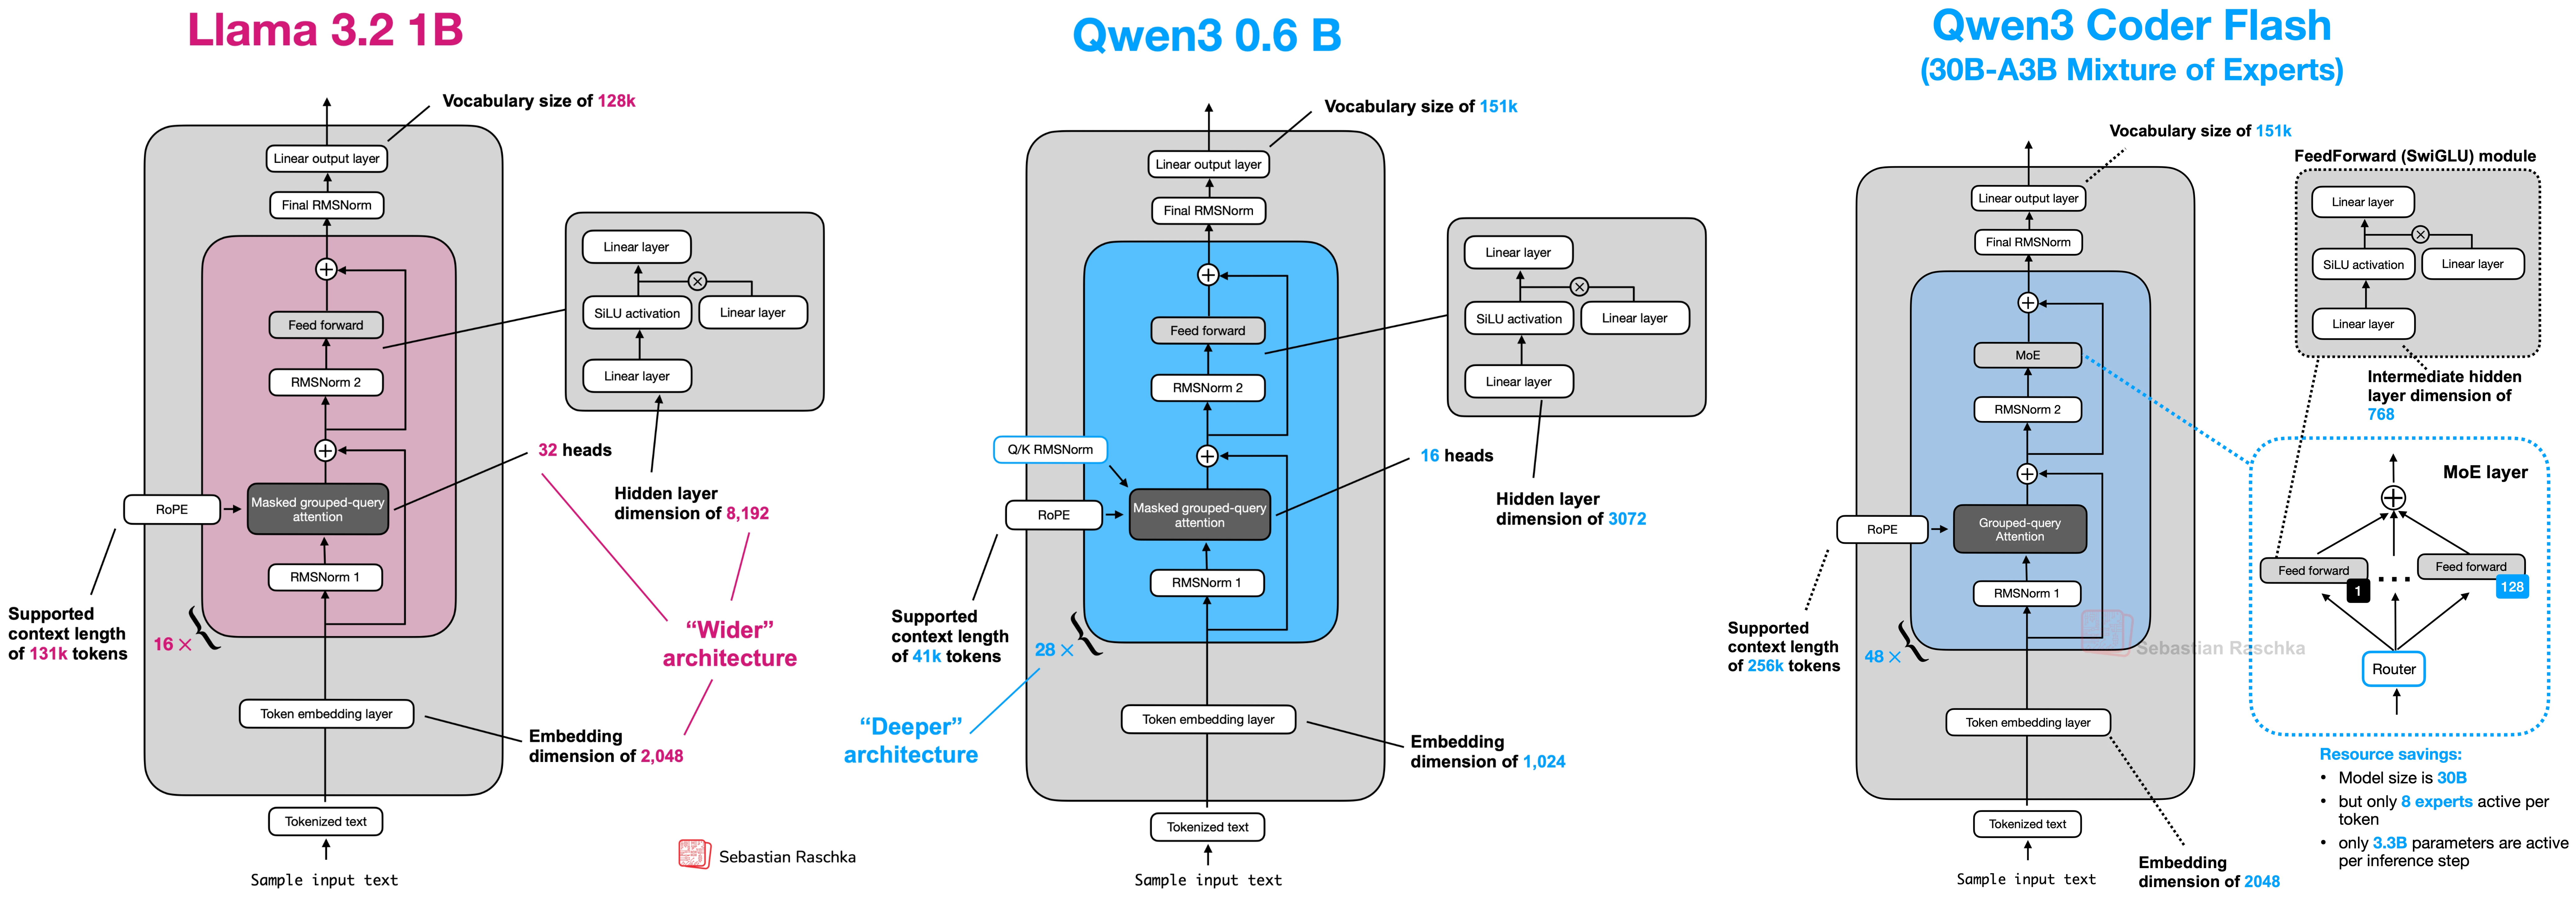

Let’s first understand the Qwen MoE architecture as an intermediate techy person, and then use an example **“the cat sat”** to see how it goes through the architecture to get a clear understanding of it.

Imagine you have a really tough job. Instead of hiring one person who *kinda* knows everything, you hire a team of specialists, each amazing at one particular thing (like an electrician, a plumber, a painter). You also hire a manager who looks at the current task and sends it to the right specialist(s).

MoE in AI models is kinda like that. Instead of one gigantic neural network trying to learn everything, an MoE layer has:

1.  **A Team of “Experts”:** These are smaller, specialized neural networks (usually simple Feed-Forward Networks or MLPs). Each expert might get good at handling certain types of information or patterns.
2.  **A “Router” (The Manager):** This is another small network. Its job is to look at the input data (like a word or part of a word) and decide which expert(s) are the best fit to handle it right now.

![Routing Mechanics overview](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*6XrqlD-nyR5cMCuNwzC_nQ.png)

Imagine our model is processing the sentence: The cat sat.

1.  Tokens: First, we break it into pieces (tokens): “The” “cat” “sat”
2.  Router Gets a Token: The MoE layer receives the token `cat` (represented as a bunch of numbers, an embedding vector). The `Router` looks at this `cat` vector.
3.  Router Chooses: Let’s say we have 4 experts (`E1`, `E2`, `E3`, `E4`). The `Router` decides which ones are best suited for `cat`.
4.  Maybe it thinks `E2` (perhaps good with nouns?) and `E4` (perhaps good with animal concepts?) are the top choices. It gives scores or "weights" to these choices (e.g., 70% for `E2`, 30% for `E4`).

![How router decided](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*QFHjewbWyfwieuXmTCzj1A.png)

The `cat` vector is sent only to `Expert 2` and `Expert 4`. `Experts 1` and `3` don't do any work for this token, saving computation! `E2` processes `cat` and generates its result (`Output_E2`). `E4` processes `cat` and generates its result (`Output_E4`).

![Chosen Experts for cat word](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*f9OpfXuwhd8-NTpC_dbEGw.png)

We now combine the results from the chosen experts using the `router` weights: `Final_Output = (0.7 * Output_E2) + (0.3 * Output_E4).`

This `Final_Output` is what the `MoE` layer passes on for the token `cat`. This happens for every token in the sequence! Different tokens might get routed to different experts.

So, when our model processes text like `"The cat sat."`, the overall journey looks like this:

![Detailed architecture](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*Po6cCxe33p2xNYd_WXVAwg.png)

`Input Text` goes into the `Tokenizer`.`Tokenizer` creates numerical `Token IDs`. `Embedding Layer` turns IDs into meaningful number vectors (`Embeddings`) and adds `Positional Info` (using `RoPE` later in attention).

These vectors go through multiple `Transformer Blocks`. Each block has:

*   `Self-Attention` (where tokens look at each other, enhanced by `RoPE`).
*   `MoE Layer` (where the `router` sends tokens to specific `experts`).
*   `Normalization` (`RMSNorm`) and `Residual connections` help learning.

The output from the last block goes to a `Final Layer`. This layer produces `Logits` (scores) for every possible next token in our vocabulary.

We convert `logits` to `Probabilities` and `Predict the Next Token`.

Now that we have a feel for how `MoE` fits into the picture, let’s dive into the code and build these components step-by-step! We’ll start by setting up our coding environment.

# Setting the Stage

We will be working with a small range of Python libraries, but it’s better to install them to avoid encountering **“no module found”** errors.

In [ ]:
# %%capture
# !pip install sentencepiece tiktoken torch matplotlib huggingface_hub tokenizers safetensors

After installing the required libraries, we need to download the Qwen 3 architecture weights and configuration files that will be used throughout this guide.

We are targeting a smaller Qwen 3 MoE version that contains two experts with 0.8B parameters each. The necessary files serve as the backbone of the Qwen 3 architecture. There are two ways to accomplish this.

**(Option 1: Manual)** Go to the [Qwen-0.8B-2E](https://huggingface.co/huihui-ai/Huihui-MoE-0.8B-2E) HF directory and manually download each of these four files.

![Manually downloading weights](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*pdffJTwdjxjjvgmHFdp1Qw.png)
*Manually downloading weights*

**(options 2: Coding)** We can use the `huggingface_hub` snapshot downloader module to download the entire Hugging Face repository of the [Qwen 3 MoE model](https://huggingface.co/huihui-ai/Huihui-MoE-0.8B-2E/tree/main). Let's proceed with this approach.

In [ ]:
# # Import tqdm for progress bars and snapshot_download for downloading model files
# from tqdm import tqdm
# from huggingface_hub import snapshot_download

# # Define the Hugging Face repository ID and the local directory to save the files
# repo_id = "huihui-ai/Huihui-MoE-0.8B-2E"
# local_dir = "Huihui-MoE-0.8B-2E"

# # Download the model snapshot from Hugging Face, excluding .bin files
# # This will fetch config, tokenizer, and safetensors weights only
# snapshot_download(
#     repo_id=repo_id,
#     local_dir=local_dir,
#     ignore_patterns=["*.bin"],      # Skip large .bin files, only get safetensors
#     tqdm_class=tqdm                # Use standard tqdm for progress bar
# )

Once all the files are downloaded, we need to import the libraries that we will be using throughout this blog.

In [1]:
# --- Core Deep Learning & Numerics ---
import torch                   # Fundamental library for tensor operations and deep learning.
import torch.nn as nn          # Provides building blocks for neural networks (layers, activations, etc.).

# --- Hugging Face Ecosystem ---
from huggingface_hub import snapshot_download # Downloads entire model repositories from the Hugging Face Hub.
from tokenizers import Tokenizer              # Loads and handles the vocabulary and tokenization logic.
from safetensors.torch import load_file       # Safely and efficiently loads model weights (.safetensors files).

# --- Data Handling & Utilities ---
import json                    # For parsing JSON files, like the model's configuration (config.json).
from pathlib import Path       # For handling filesystem paths in an object-oriented, OS-agnostic way.
from tqdm import tqdm          # For displaying progress bars during downloads or long computations.

# --- Visualization ---
import matplotlib.pyplot as plt # For creating plots and heatmaps to visualize attention scores.

Next, we need to understand what each file will be used for.

# Why we need Model Weights?

Since we are aiming for an exact replication of Qwen 3 MoE, it means our input text must yield a meaningful output. For example, if our input is **“the color of the sun is?”**, the output must be **“white”**. Achieving this requires training our LLM on a large dataset, which demands high computation power, making it unfeasible for us.

However, [Alibaba has publicly released their Qwen 3 architecture files](https://github.com/QwenLM/Qwen3), or in more complex terms, their pretrained weights, for use. We’ve just downloaded these files, allowing us to replicate their architecture without the need for training or a large dataset. Everything is already prepared, we just have to use the right components in the right places.

**tokenizer.json** — Qwen 3 uses Byte Pair Encoding (BPE), It’s basically a subword tokenization algorithm. It starts with a vocabulary of individual characters and iteratively merges the most frequent pair of adjacent tokens until it reaches a desired vocabulary size. This allows it to handle unknown words and create a more efficient vocabulary.

In [2]:
# This file contains the vocabulary, merge rules, and configuration.
tokenizer_path = Path("Huihui-MoE-0.8B-2E/tokenizer.json")

# The Tokenizer.from_file() method is the standard way to load tokenizers
# from the Hugging Face ecosystem.
tokenizer = Tokenizer.from_file(str(tokenizer_path))

# We can also load them from the special_tokens_map.json for confirmation
with open("Huihui-MoE-0.8B-2E/special_tokens_map.json", "r") as f:
    special_tokens_map = json.load(f)
    print(f"Special tokens from file: {special_tokens_map}")

Special tokens from file: {'additional_special_tokens': ['<|im_start|>', '<|im_end|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_start|>', '<|vision_end|>', '<|vision_pad|>', '<|image_pad|>', '<|video_pad|>'], 'eos_token': {'content': '<|im_end|>', 'lstrip': False, 'normalized': False, 'rstrip': False, 'single_word': False}, 'pad_token': {'content': '<|endoftext|>', 'lstrip': False, 'normalized': False, 'rstrip': False, 'single_word': False}}


These special token is what we will be using to wrap our prompt that will guide our Qwen 3 Architecture to how to respond to our queries.

In [3]:
# We'll follow the encode -> decode pattern to ensure it works correctly.
prompt = "The only thing I know is that I know"

# .encode() returns an Encoding object, we access the token IDs via .ids
encoded = tokenizer.encode(prompt)
print(f"\nOriginal prompt: '{prompt}'")
print(f"Encoded token IDs: {encoded.ids}")

# .decode() converts the token IDs back to a string.
decoded = tokenizer.decode(encoded.ids)
print(f"Decoded back to text: '{decoded}'")

# Verify the vocabulary size
vocab_size = tokenizer.get_vocab_size()
print(f"\nTokenizer vocabulary size: {vocab_size}")


Original prompt: 'The only thing I know is that I know'
Encoded token IDs: [785, 1172, 3166, 358, 1414, 374, 429, 358, 1414]
Decoded back to text: 'The only thing I know is that I know'

Tokenizer vocabulary size: 151669


The vocabulary size represent the unique number of characters in the training data. The type of `tokenizer` is a dictionary.

In [4]:
# Get the vocabulary as a dictionary: {token_string: token_id}
vocab = tokenizer.get_vocab()

# Display a slice of the vocabulary for inspection (tokens 5600 to 5609)
sample_vocab_slice = list(vocab.items())[5600:5610]
sample_vocab_slice

[('.setHorizontalAlignment', 69959),
 ('Ġmatrix', 6172),
 ('ptoms', 51173),
 ('Ġac', 1613),
 ('abama', 18884),
 ('Ġ×Ĵ×ĵ', 126527),
 ('ĠìķĬëĬĶ', 127728),
 ('ðĿķ«', 149160),
 ('Ġpel', 11814),
 ('Ġiht', 127648)]

When we print 10 random items from it, you will see strings that have been formed using the BPE algorithm. Keys representing Byte sequences from BPE training, while values represent merge ranks based on frequency.

**config.json** — contains various parameter values, such as:

In [5]:
# Define the path to the configuration file.
config_path = Path("Huihui-MoE-0.8B-2E/config.json")

# Open and load the JSON file into a Python dictionary.
with open(config_path, "r") as f:
    config = json.load(f)

# Print the configuration to see all the parameters.
# This gives us a complete overview of the model we're about to build.
print(json.dumps(config, indent=4))

{
    "architectures": [
        "Qwen3MoeForCausalLM"
    ],
    "attention_bias": false,
    "attention_dropout": 0.0,
    "bos_token_id": 151643,
    "decoder_sparse_step": 1,
    "eos_token_id": 151645,
    "head_dim": 128,
    "hidden_act": "silu",
    "hidden_size": 1024,
    "initializer_range": 0.02,
    "intermediate_size": 3072,
    "max_position_embeddings": 40960,
    "max_window_layers": 28,
    "mlp_only_layers": [],
    "model_type": "qwen3_moe",
    "moe_intermediate_size": 3072,
    "norm_topk_prob": true,
    "num_attention_heads": 16,
    "num_experts": 2,
    "num_experts_per_tok": 1,
    "num_hidden_layers": 28,
    "num_key_value_heads": 8,
    "output_router_logits": false,
    "rms_norm_eps": 1e-06,
    "rope_scaling": null,
    "rope_theta": 1000000,
    "router_aux_loss_coef": 0.001,
    "sliding_window": null,
    "tie_word_embeddings": true,
    "torch_dtype": "bfloat16",
    "transformers_version": "4.52.4",
    "use_cache": true,
    "use_sliding_window": 

These values will help us replicate the Qwen-3 architecture by specifying details like the number of heads, dimension of the embedding vector, number of experts and more.

Let’s store these values so we can use them later.

In [6]:
# --- Main Architecture Parameters ---
# Extract model hyperparameters from the config dictionary.

# Embedding dimension (hidden size of the model)
dim = config["hidden_size"]
# Number of transformer layers
n_layers = config["num_hidden_layers"]
# Number of attention heads
n_heads = config["num_attention_heads"]
# Number of key/value heads (for grouped-query attention)
n_kv_heads = config["num_key_value_heads"]
# Vocabulary size
vocab_size = config["vocab_size"]
# RMSNorm epsilon value for numerical stability
norm_eps = config["rms_norm_eps"]
# Rotary positional embedding theta parameter
rope_theta = torch.tensor(config["rope_theta"])
# Dimension of each attention head
head_dim = config["head_dim"]  # For attention calculations

# --- Mixture-of-Experts (MoE) Specific Parameters ---
# Number of experts in the MoE layer
num_experts = config["num_experts"]
# Number of experts selected per token by the router
num_experts_per_tok = config["num_experts_per_tok"]
# Intermediate size of the MoE feed-forward network
moe_intermediate_size = config["moe_intermediate_size"]

In [7]:
# --- Print out all key architecture parameters for verification ---
print(f"Embedding Dimension (dim): {dim}")
print(f"Number of Layers (n_layers): {n_layers}")
print(f"Number of Heads (n_heads): {n_heads}")
print(f"Number of KV Heads (n_kv_heads): {n_kv_heads}")
print(f"Head Dimension (head_dim): {head_dim}")  # <-- Print head_dim for clarity
print(f"Vocabulary Size (vocab_size): {vocab_size}")
print(f"RoPE Theta: {rope_theta}")
print(f"--- MoE Params ---")
print(f"Total Experts (num_experts): {num_experts}")
print(f"Experts per Token (num_experts_per_tok): {num_experts_per_tok}")
print(f"MoE Intermediate Size: {moe_intermediate_size}")

Embedding Dimension (dim): 1024
Number of Layers (n_layers): 28
Number of Heads (n_heads): 16
Number of KV Heads (n_kv_heads): 8
Head Dimension (head_dim): 128
Vocabulary Size (vocab_size): 151936
RoPE Theta: 1000000
--- MoE Params ---
Total Experts (num_experts): 2
Experts per Token (num_experts_per_tok): 1
MoE Intermediate Size: 3072


**model.safetensors**— contains the learned parameters (weights) of Qwen 0.8B 2Experts. These parameters include information about how the model understands and processes language, such as how it represents tokens, computes attention, performs experts selection, and normalizes its outputs.

In [8]:
# Define the path to the model weights file
model_weights_path = Path("Huihui-MoE-0.8B-2E/model.safetensors")

# Load the weights into a dictionary; each key is a layer/parameter name, and each value is a torch tensor
model_weights = load_file(model_weights_path)

# Inspect the loaded weights: print the first 20 layer names to confirm successful loading
print("First 20 keys in model_weights:")
print(json.dumps(list(model_weights.keys())[:20], indent=4))

First 20 keys in model_weights:
[
    "model.embed_tokens.weight",
    "model.layers.0.input_layernorm.weight",
    "model.layers.0.mlp.experts.0.down_proj.weight",
    "model.layers.0.mlp.experts.0.gate_proj.weight",
    "model.layers.0.mlp.experts.0.up_proj.weight",
    "model.layers.0.mlp.experts.1.down_proj.weight",
    "model.layers.0.mlp.experts.1.gate_proj.weight",
    "model.layers.0.mlp.experts.1.up_proj.weight",
    "model.layers.0.mlp.gate.weight",
    "model.layers.0.post_attention_layernorm.weight",
    "model.layers.0.self_attn.k_norm.weight",
    "model.layers.0.self_attn.k_proj.weight",
    "model.layers.0.self_attn.o_proj.weight",
    "model.layers.0.self_attn.q_norm.weight",
    "model.layers.0.self_attn.q_proj.weight",
    "model.layers.0.self_attn.v_proj.weight",
    "model.layers.1.input_layernorm.weight",
    "model.layers.1.mlp.experts.0.down_proj.weight",
    "model.layers.1.mlp.experts.0.gate_proj.weight",
    "model.layers.1.mlp.experts.0.up_proj.weight"
]


If you’re familiar with transformer architecture, you would have known about query, key matrices, and more. Later, we will be using these layers/weights to create such matrices along with MoE component within the architecture of Qwen 3 MoE.

Now that we have the tokenizer model, architecture model containing weights, and configuration parameters, let’s start coding our own Qwen 3 MoE from scratch.

# Tokenized Text

![Tokenizing Input Text](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*VDaYccYFCsNLE52RmjRe4A.png)
*Tokenizing Input Text (Created by Fareed Khan)*

The very first step is to convert our input text into tokens. Qwen 3 uses a specific chat template with special tokens like `<|im_start|>` and `<|im_end|>` to structure the conversation. This helps the model differentiate between user queries and its own responses.

In [9]:
# Our sample user prompt
prompt = "The only thing I know is that I know"

# Get token IDs for special tokens and template components
im_start_id = tokenizer.token_to_id("<|im_start|>")
im_end_id = tokenizer.token_to_id("<|im_end|>")
newline_id = tokenizer.encode("\n").ids[0]
user_ids = tokenizer.encode("user").ids
assistant_ids = tokenizer.encode("assistant").ids
prompt_ids = tokenizer.encode(prompt).ids

# Manually construct the full prompt using the chat template:
# <|im_start|>user\n{prompt}<|im_end|>\n<|im_start|>assistant\n
prefix_ids = [im_start_id] + user_ids + [newline_id]
suffix_ids = [im_end_id, newline_id, im_start_id] + assistant_ids + [newline_id]
tokens_list = prefix_ids + prompt_ids + suffix_ids

# Convert the list of token IDs into a PyTorch tensor
tokens = torch.tensor(tokens_list)

print(f"Final combined token IDs: {tokens}")

# Decode for verification
prompt_split_as_tokens = [tokenizer.decode([token.item()]) for token in tokens]
print(f"\nPrompt split into tokens: {prompt_split_as_tokens}")

Final combined token IDs: tensor([151644,    872,    198,    785,   1172,   3166,    358,   1414,    374,
           429,    358,   1414, 151645,    198, 151644,  77091,    198])

Prompt split into tokens: ['', 'user', '\n', 'The', ' only', ' thing', ' I', ' know', ' is', ' that', ' I', ' know', '', '\n', '', 'assistant', '\n']


We’ve now converted our prompt into a structured list of 17 tokens, ready for the model.

![Generating Embeddings of Tokenized Text](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*VVjqGJH09REwPLZ0vYR37A.png)
*Generating Embeddings of Tokenized Text (Created by Fareed Khan)*

An embedding is a dense vector that represents a token’s meaning in a high-dimensional space. Our input vector of 17 tokens needs to be converted into a `[17, 1024]` tensor, where 1024 (`dim`) is the embedding dimension.

In [10]:
# Initialize the embedding layer with the correct size
embedding_layer = nn.Embedding(vocab_size, dim)
# Load the pre-trained weights into our layer
embedding_layer.weight.data.copy_(model_weights["model.embed_tokens.weight"])

# Pass our tokens through the layer to get their embeddings
token_embeddings_unnormalized = embedding_layer(tokens).to(torch.bfloat16)

# Verify the shape
print("Shape of the token embeddings:", token_embeddings_unnormalized.shape)

Shape of the token embeddings: torch.Size([17, 1024])


These embeddings are not normalized, and it will have a serious effect if we don’t normalize them. In the next section, we will perform normalization on our input vectors.

# Normalization Using RMSNorm

We’ll define our `rms_norm` function, which scales the input based on its root mean square value. This is the first pre-normalization step in our transformer layer.

![Root Mean Square Layer Normalization Paper](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*an_Sz8wvLW7H5Y3cChnHwA.png)
*Root Mean Square Layer Normalization Paper ([https://arxiv.org/abs/1910.07467](https://arxiv.org/abs/1910.07467))*

In [11]:
# RMSNorm function: scales the input tensor by the reciprocal of its root mean square
def rms_norm(tensor, norm_weights):
    input_dtype = tensor.dtype
    tensor_float = tensor.to(torch.float32)
    # Calculate the variance (mean of squares)
    variance = tensor_float.pow(2).mean(-1, keepdim=True)
    # Normalize by multiplying with the reciprocal square root of the variance
    normalized_tensor = tensor_float * torch.rsqrt(variance + norm_eps)
    # Apply the learnable weights and cast back to the original dtype
    return (normalized_tensor * norm_weights).to(input_dtype)

We will use the attention weights from layers_0 to normalize our unnormalized embeddings. The reason for using layer_0 is that we are now creating the first layer of our Qwen 3 architecture.

In [12]:
# Apply RMSNorm to the embeddings using the weights 
# for the first layer's input
token_embeddings_normalized = rms_norm(
    token_embeddings_unnormalized, 
    model_weights["model.layers.0.input_layernorm.weight"]
)
print("Shape of the normalized token embeddings:", token_embeddings_normalized.shape)

Shape of the normalized token embeddings: torch.Size([17, 1024])


The shape remains the same, but the values are now normalized and ready for the attention mechanism.

# Grouped-Query Attention (GQA)

Next, we generate the Query (Q), Key (K), and Value (V) vectors. The pre-trained weights are stored in large, combined matrices. We need to reshape them to isolate the weights for each of our 16 attention heads.

![Grouped-Query Attention (GQA)](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*fcf_EDASd1SBRncR0bY1mQ.png)
*Grouped-Query Attention (GQA) Created by Fareed Khan*

This model uses an optimization called **Grouped-Query Attention (GQA)**, where multiple Query heads (16) share a smaller number of Key and Value heads (8). This reduces the computational load without a significant loss in performance.

In [13]:
# Unpack the query weights into 16 heads
q_layer0 = model_weights["model.layers.0.self_attn.q_proj.weight"]
q_layer0 = q_layer0.view(n_heads, head_dim, dim)

# Unpack the key weights into 8 shared heads
k_layer0 = model_weights["model.layers.0.self_attn.k_proj.weight"]
k_layer0 = k_layer0.view(n_kv_heads, head_dim, dim)

# Unpack the value weights into 8 shared heads
v_layer0 = model_weights["model.layers.0.self_attn.v_proj.weight"]
v_layer0 = v_layer0.view(n_kv_heads, head_dim, dim)

Now, let’s calculate the Q, K, and V vectors for the first head by multiplying our normalized embeddings by the head’s weights.

In [14]:
# Get the weights for the first head (head 0)
q_layer0_head0 = q_layer0[0]
k_layer0_head0 = k_layer0[0] # The first Q head uses the first KV head
v_layer0_head0 = v_layer0[0]

# Calculate the Q, K, and V vectors for each of the 17 tokens
q_per_token = torch.matmul(token_embeddings_normalized, q_layer0_head0.T)
k_per_token = torch.matmul(token_embeddings_normalized, k_layer0_head0.T)
v_per_token = torch.matmul(token_embeddings_normalized, v_layer0_head0.T)

# Verify the shape of the query vectors
print("Shape of Query vectors per token:", q_per_token.shape)

Shape of Query vectors per token: torch.Size([17, 128])


Each of our 17 tokens now has a 128-dimensional Q, K, and V vector for the first head.

# Implementing RoPE

These vectors don’t yet know their position. We’ll use RoPE to inject this information by “rotating” them. For efficiency, we can pre-compute the rotation angles for all possible positions up to the maximum sequence length.

![RoPE Implementation](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*TsL66Fs4iyyiuHbxurnekw.png)
*RoPE Implementation (Created by Fareed Khan)*

This creates a lookup table of rotation matrices, represented as complex numbers.

In [15]:
# Pre-compute RoPE frequencies for all possible positions
max_seq_len = config["max_position_embeddings"]
freqs = 1.0 / (rope_theta ** (torch.arange(0, head_dim, 2) / head_dim))
t = torch.arange(max_seq_len)
freqs_for_each_token = torch.outer(t, freqs)
# `freqs_cis` is our lookup table of complex numbers for rotation
freqs_cis = torch.polar(torch.ones_like(freqs_for_each_token), freqs_for_each_token)

This `freqs_cis` tensor now holds the complex numbers that will perform the rotation. We can visualize the rotations for a single token to see how each 2D pair of dimensions is rotated by a different angle.

![RoPE Rotations for each 2D-pair at a single token position](https://miro.medium.com/v2/resize:fit:709/1*pafyhHC9KOT2s5bj0A1wsg.png)
*RoPE Rotations for each 2D-pair at a single token position (Created by Fareed Khan)*

Now, we apply these rotations to our Q and K vectors. The rotation is performed by viewing the vectors as complex numbers and doing an element-wise multiplication.


In [16]:
# Get the pre-computed rotations for our sequence of 17 tokens
freqs_cis_for_tokens = freqs_cis[:len(tokens)]

# --- Apply RoPE to Query vectors ---
# Reshape [17, 128] to [17, 64, 2] and view as complex numbers [17, 64]
q_per_token_as_complex_numbers = torch.view_as_complex(q_per_token.float().view(q_per_token.shape[0], -1, 2))
# Apply rotation via complex multiplication
q_per_token_rotated_complex = q_per_token_as_complex_numbers * freqs_cis_for_tokens
# Convert back to real numbers and reshape to [17, 128]
q_per_token_rotated = torch.view_as_real(q_per_token_rotated_complex).view(q_per_token.shape)

# --- Apply RoPE to Key vectors (same process) ---
k_per_token_as_complex_numbers = torch.view_as_complex(k_per_token.float().view(k_per_token.shape[0], -1, 2))
k_per_token_rotated_complex = k_per_token_as_complex_numbers * freqs_cis_for_tokens
k_per_token_rotated = torch.view_as_real(k_per_token_rotated_complex).view(k_per_token.shape)

print("Shape of rotated Query vectors:", q_per_token_rotated.shape)

Shape of rotated Query vectors: torch.Size([17, 128])


# Calculating Attention Scores

Now we calculate the attention scores by taking the dot product of the query and key matrices. This creates a `[17, 17]` matrix showing how much each token should "attend" to every other token.

We scale the scores by the square root of the head dimension to stabilize training.


In [17]:
# Calculate dot product of Q and K to get attention scores
qk_per_token = torch.matmul(q_per_token_rotated, k_per_token_rotated.T)
# Scale the scores for numerical stability
qk_per_token_scaled = qk_per_token / (head_dim**0.5)

We can visualize these raw scores as a heatmap.

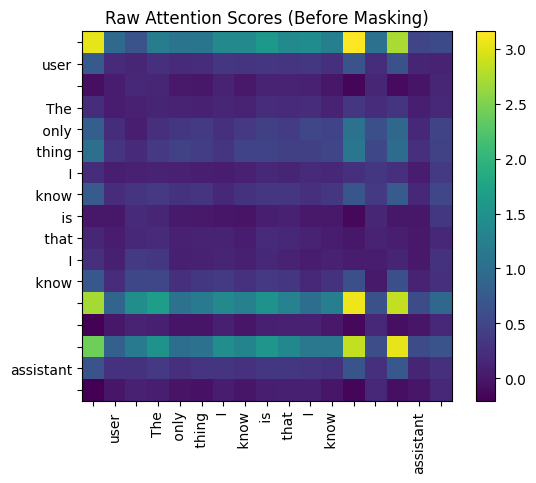

In [18]:
# Calculate the raw attention scores by multiplying rotated Q and K vectors
qk_per_token = torch.matmul(q_per_token_rotated, k_per_token_rotated.T)

# Scale the attention scores by the square root of the head dimension
qk_per_token_scaled = qk_per_token / (head_dim**0.5)

# Visualize the raw attention scores before masking
def display_qk_heatmap(qk_matrix, title="Attention Heatmap"):
    _, ax = plt.subplots()
    im = ax.imshow(qk_matrix.to(torch.float32).detach(), cmap='viridis')
    ax.set_xticks(range(len(prompt_split_as_tokens)))
    ax.set_yticks(range(len(prompt_split_as_tokens)))
    ax.set_xticklabels(prompt_split_as_tokens, rotation=90)
    ax.set_yticklabels(prompt_split_as_tokens)
    ax.figure.colorbar(im, ax=ax)
    plt.title(title)
    plt.show()

display_qk_heatmap(qk_per_token_scaled, title="Raw Attention Scores (Before Masking)")

To prevent tokens from “seeing” into the future in this auto-regressive model, we apply a **causal mask**. This sets all scores in the upper triangle of the matrix to negative infinity, so they become zero after the softmax function.

In [19]:
# Create an upper-triangular mask with -inf values
mask = torch.full((len(tokens), len(tokens)), float("-inf"))
mask = torch.triu(mask, diagonal=1)

# Apply the mask to the scores
qk_per_token_masked = qk_per_token_scaled + mask

If we look how mask matrix looks like.

In [20]:
# Printing masking approach
print(mask)

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -in

![Attention Scores After Masking](https://miro.medium.com/v2/resize:fit:670/1*E6dZs4NWDhlzvD9537o8PQ.png)
*Attention Scores After Masking (Created by Fareed Khan)*

Finally, we apply the **softmax** function to convert these scores into probabilities (attention weights) and multiply them by the Value matrix. This produces a weighted sum of the values, giving us the final output for this attention head.

In [21]:
# Apply softmax to turn scores into probabilities
qk_per_token_after_masking_after_softmax = torch.nn.functional.softmax(qk_per_token_masked.float(), dim=1).to(torch.bfloat16)
# Multiply the attention weights by the Value vectors
qkv_attention = torch.matmul(qk_per_token_after_masking_after_softmax, v_per_token)

print("Shape of the final attention output for Head 0:", qkv_attention.shape)


Shape of the final attention output for Head 0: torch.Size([17, 128])


![Final Attention Weights](https://miro.medium.com/v2/resize:fit:670/1*9PItTAS0NWLnrBqUQX7rpA.png)
*Final Attention Weights (Created by Fareed Khan)*

The output is a new `[17, 128]` tensor where each token's vector now contains contextual information from all preceding tokens.

# Implementing Multi-Head Attention

We now repeat the self-attention process for all 16 heads in a loop. The outputs of each head, which are `[17, 128]` tensors, are collected in a list.

![Multi Head attention](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*gUEUUNCP0RCATxtVRdL-4w.png)
*Multi Head attention (Created by Fareed Khan)*

In [22]:
# Create an empty list to store the attention output of each head.
qkv_attention_store = []

# Iterate over each of the 16 attention heads.
for head in range(n_heads):
    # Get the Q, K, and V weights for the current head.
    # Note the use of `head // 4` for K and V due to Grouped-Query Attention.
    # Every 4 query heads share the same key and value heads.
    q_layer0_head = q_layer0[head]
    k_layer0_head = k_layer0[head // (n_heads // n_kv_heads)]
    v_layer0_head = v_layer0[head // (n_heads // n_kv_heads)]

    # Project the normalized embeddings into Q, K, and V vectors for this head.
    q_per_token = torch.matmul(token_embeddings_normalized, q_layer0_head.T)
    k_per_token = torch.matmul(token_embeddings_normalized, k_layer0_head.T)
    v_per_token = torch.matmul(token_embeddings_normalized, v_layer0_head.T)

    # Apply RoPE to the Q and K vectors for this head.
    q_per_token_split_into_pairs = q_per_token.float().view(q_per_token.shape[0], -1, 2)
    q_per_token_as_complex_numbers = torch.view_as_complex(q_per_token_split_into_pairs)
    q_per_token_as_complex_numbers_rotated = q_per_token_as_complex_numbers * freqs_cis_for_tokens
    q_per_token_split_into_pairs_rotated = torch.view_as_real(q_per_token_as_complex_numbers_rotated)
    q_per_token_rotated = q_per_token_split_into_pairs_rotated.view(q_per_token.shape)

    k_per_token_split_into_pairs = k_per_token.float().view(k_per_token.shape[0], -1, 2)
    k_per_token_as_complex_numbers = torch.view_as_complex(k_per_token_split_into_pairs)
    k_per_token_as_complex_numbers_rotated = k_per_token_as_complex_numbers * freqs_cis_for_tokens
    k_per_token_split_into_pairs_rotated = torch.view_as_real(k_per_token_as_complex_numbers_rotated)
    k_per_token_rotated = k_per_token_split_into_pairs_rotated.view(k_per_token.shape)

    # Calculate and scale the attention scores.
    qk_per_token = torch.matmul(q_per_token_rotated, k_per_token_rotated.T) / (head_dim**0.5)

    # Apply the causal mask.
    qk_per_token_masked = qk_per_token + mask

    # Apply softmax to get the attention weights.
    qk_per_token_after_masking_after_softmax = torch.nn.functional.softmax(qk_per_token_masked.float(), dim=1).to(torch.bfloat16)

    # Aggregate the Value vectors using the attention weights.
    qkv_attention = torch.matmul(qk_per_token_after_masking_after_softmax, v_per_token)
    
    # Append the result of this head to our list.
    qkv_attention_store.append(qkv_attention)

After the loop, we concatenate the 16 head outputs into a single large tensor of size `[17, 2048]`. This is then projected back down to our model's dimension (`1024`) using the output weight matrix `o_proj`.

In [23]:
# Concatenate the outputs from all 16 heads along the last dimension
stacked_qkv_attention = torch.cat(qkv_attention_store, dim=-1)

# Get the output projection weights
w_layer0 = model_weights["model.layers.0.self_attn.o_proj.weight"]

# Project the concatenated outputs back to the model's hidden dimension
embedding_delta = torch.matmul(stacked_qkv_attention, w_layer0.T)

The result, `embedding_delta`, is added back to the original input of the layer. This is the first **residual connection**, a crucial technique that helps in training very deep networks by allowing gradients to flow more easily.

In [24]:
# Add the output of the attention block back to its input (residual connection)
embedding_after_attention = token_embeddings_unnormalized + embedding_delta

# Mixture-of-Experts (MoE) Block

This is the second sub-layer of the transformer block. First, we apply pre-normalization to its input.

![Qwen 3 MoE Layer](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*dibQD1Bkr3oj6xROSonAOQ.png)
*Qwen 3 MoE Layer (Created by Fareed Khan)*

In [25]:
# Apply RMSNorm before the MoE block, using the 'post_attention_layernorm' weights
embedding_after_attention_normalized = rms_norm(
    embedding_after_attention, 
    model_weights["model.layers.0.post_attention_layernorm.weight"]
)

Next, the **router** (a simple linear layer) calculates scores to determine which of the two experts each token should be sent to.

In [26]:
# --- Step 1: The MoE Router ---
# The router is a simple linear layer that determines which expert to send each token to.
# It projects our [17, 1024] tensor to a [17, num_experts] tensor of scores (logits).
gate = model_weights["model.layers.0.mlp.gate.weight"]
router_logits = torch.matmul(embedding_after_attention_normalized, gate.T)

# We apply softmax to the logits to get probabilities, and then find the expert with the
# highest probability for each token.
routing_weights = torch.nn.functional.softmax(router_logits.float(), dim=1).to(torch.bfloat16)
routing_expert_indices = torch.argmax(routing_weights, dim=1)

print("Router logits shape:", router_logits.shape)
print("Expert chosen for each of the 17 tokens:", routing_expert_indices)

# --- Step 2: The Expert Layers ---
# Each expert is a SwiGLU-style Feed-Forward Network.
expert0_w1 = model_weights["model.layers.0.mlp.experts.0.gate_proj.weight"]
expert0_w2 = model_weights["model.layers.0.mlp.experts.0.down_proj.weight"]
expert0_w3 = model_weights["model.layers.0.mlp.experts.0.up_proj.weight"]

expert1_w1 = model_weights["model.layers.0.mlp.experts.1.gate_proj.weight"]
expert1_w2 = model_weights["model.layers.0.mlp.experts.1.down_proj.weight"]
expert1_w3 = model_weights["model.layers.0.mlp.experts.1.up_proj.weight"]

# --- Step 3: Process tokens with their chosen expert ---
final_expert_output = torch.zeros_like(embedding_after_attention_normalized)

Router logits shape: torch.Size([17, 2])
Expert chosen for each of the 17 tokens: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In this case, the router decided to send all 17 tokens to expert 1. We now process each token’s embedding through its chosen expert’s feed-forward network (FFN) and combine the results, weighted by the router’s probabilities.

In [27]:
# Initialize a tensor to store the final output from the experts
final_expert_output = torch.zeros_like(embedding_after_attention_normalized)

# Loop through each token and process it with its chosen expert
for i, token_embedding in enumerate(embedding_after_attention_normalized):
    chosen_expert_index = routing_expert_indices[i]

    # (Get weights for the chosen expert and apply the FFN logic)
    # Get the weights for the chosen expert
    if chosen_expert_index == 0:
        w1, w2, w3 = expert0_w1, expert0_w2, expert0_w3
    else:
        w1, w2, w3 = expert1_w1, expert1_w2, expert1_w3
    
    # Apply the SwiGLU activation for this token's chosen expert
    silu_output = torch.nn.functional.silu(torch.matmul(token_embedding, w1.T))
    gated_output = silu_output * torch.matmul(token_embedding, w3.T)
    expert_output = torch.matmul(gated_output, w2.T)

    # Weight the expert's output by its routing probability
    final_expert_output[i] = expert_output * routing_weights[i, chosen_expert_index]

Finally, we add the output of the MoE block back to the output of the attention block. This is the second **residual connection**, completing the transformer layer.

In [28]:
# Second residual connection: add the output of the MoE block to its input
layer_0_embedding = embedding_after_attention + final_expert_output

# Merging everything

Now that we have all the components, we can build the full model by looping through all 28 layers.

The output of one layer becomes the input to the next.

In [29]:
# The final embedding starts as the output from the token embedding layer.
# We will update this tensor in-place as it passes through the layers.
final_embedding = token_embeddings_unnormalized

# Loop through each of the 28 layers of the transformer.
for layer in range(n_layers):
    
    # --- Attention Sub-Layer ---
    
    # 1. RMS Normalization before attention
    attention_input = rms_norm(final_embedding, model_weights[f"model.layers.{layer}.input_layernorm.weight"])
    
    # 2. Multi-Head Attention
    q_layer = model_weights[f"model.layers.{layer}.self_attn.q_proj.weight"].view(n_heads, head_dim, dim)
    k_layer = model_weights[f"model.layers.{layer}.self_attn.k_proj.weight"].view(n_kv_heads, head_dim, dim)
    v_layer = model_weights[f"model.layers.{layer}.self_attn.v_proj.weight"].view(n_kv_heads, head_dim, dim)
    w_layer = model_weights[f"model.layers.{layer}.self_attn.o_proj.weight"]
    
    qkv_attention_store = []
    for head in range(n_heads):
        q_layer_head = q_layer[head]
        k_layer_head = k_layer[head // (n_heads // n_kv_heads)]
        v_layer_head = v_layer[head // (n_heads // n_kv_heads)]

        q_per_token = torch.matmul(attention_input, q_layer_head.T)
        k_per_token = torch.matmul(attention_input, k_layer_head.T)
        v_per_token = torch.matmul(attention_input, v_layer_head.T)

        q_per_token_rotated = torch.view_as_real(torch.view_as_complex(q_per_token.float().view(q_per_token.shape[0], -1, 2)) * freqs_cis_for_tokens).view(q_per_token.shape)
        k_per_token_rotated = torch.view_as_real(torch.view_as_complex(k_per_token.float().view(k_per_token.shape[0], -1, 2)) * freqs_cis_for_tokens).view(k_per_token.shape)
        
        qk_per_token = torch.matmul(q_per_token_rotated, k_per_token_rotated.T) / (head_dim**0.5)
        qk_per_token_masked = qk_per_token + mask
        qk_per_token_after_masking_after_softmax = torch.nn.functional.softmax(qk_per_token_masked.float(), dim=1).to(torch.bfloat16)
        
        qkv_attention = torch.matmul(qk_per_token_after_masking_after_softmax, v_per_token)
        qkv_attention_store.append(qkv_attention)
        
    stacked_qkv_attention = torch.cat(qkv_attention_store, dim=-1)
    embedding_delta = torch.matmul(stacked_qkv_attention, w_layer.T)
    
    # 3. First Residual Connection
    embedding_after_attention = final_embedding + embedding_delta
    
    # --- Mixture-of-Experts Sub-Layer ---
    
    # 1. RMS Normalization before MoE
    moe_input = rms_norm(embedding_after_attention, model_weights[f"model.layers.{layer}.post_attention_layernorm.weight"])
    
    # 2. Router
    gate = model_weights[f"model.layers.{layer}.mlp.gate.weight"]
    router_logits = torch.matmul(moe_input, gate.T)
    routing_weights = torch.nn.functional.softmax(router_logits.float(), dim=1).to(torch.bfloat16)
    routing_expert_indices = torch.argmax(routing_weights, dim=1)
    
    # 3. Expert Layers
    final_expert_output = torch.zeros_like(moe_input)
    
    expert0_w1 = model_weights[f"model.layers.{layer}.mlp.experts.0.gate_proj.weight"]
    expert0_w2 = model_weights[f"model.layers.{layer}.mlp.experts.0.down_proj.weight"]
    expert0_w3 = model_weights[f"model.layers.{layer}.mlp.experts.0.up_proj.weight"]

    expert1_w1 = model_weights[f"model.layers.{layer}.mlp.experts.1.gate_proj.weight"]
    expert1_w2 = model_weights[f"model.layers.{layer}.mlp.experts.1.down_proj.weight"]
    expert1_w3 = model_weights[f"model.layers.{layer}.mlp.experts.1.up_proj.weight"]
    
    for i, token_embedding in enumerate(moe_input):
        chosen_expert_index = routing_expert_indices[i]
        
        if chosen_expert_index == 0:
            w1, w2, w3 = expert0_w1, expert0_w2, expert0_w3
        else:
            w1, w2, w3 = expert1_w1, expert1_w2, expert1_w3
        
        silu_output = torch.nn.functional.silu(torch.matmul(token_embedding, w1.T))
        gated_output = silu_output * torch.matmul(token_embedding, w3.T)
        expert_output = torch.matmul(gated_output, w2.T)
        
        final_expert_output[i] = expert_output * routing_weights[i, chosen_expert_index]
        
    # 4. Second Residual Connection
    final_embedding = embedding_after_attention + final_expert_output

In [30]:
# --- Verify the final shape ---
print("Shape of the final embeddings after all layers:", final_embedding.shape)

Shape of the final embeddings after all layers: torch.Size([17, 1024])


# Generating the Output

We now have the final embedding, which represents the model’s prediction for the next token. Its shape is `[17, 1024]`. First, we apply one last RMSNorm.

In [31]:
# Apply the final layer normalization
final_embedding_normalized = rms_norm(final_embedding, model_weights["model.norm.weight"])

To get the final prediction, we only need the embedding for the very last token in our sequence. We multiply this `[1024]` vector by the language model head weights (which are tied to the token embedding weights) to get scores, or **logits**, for every word in the vocabulary.

In [32]:
# The LM Head weights are the same as the embedding weights (weight tying)
lm_head_weights = model_weights["model.embed_tokens.weight"]

# We only care about the last token's output to predict the next token
last_token_embedding = final_embedding_normalized[-1]

# Calculate the logits by multiplying with the LM Head
logits = torch.matmul(last_token_embedding, lm_head_weights.T)

print("Shape of the final logits:", logits.shape)

Shape of the final logits: torch.Size([151936])


The token with the highest logit is our model’s prediction. We use `argmax` to find its index.

In [33]:
# Find the token ID with the highest score
next_token_id = torch.argmax(logits, dim=-1)
print(f"Predicted Token ID: {next_token_id.item()}")

# Decode the ID back to a string to see the predicted word
predicted_word = tokenizer.decode([next_token_id.item()])
print(f"\nPredicted Word: '{predicted_word}'")

Predicted Token ID: 64088

Predicted Word: 'stem'
